![logo_ironhack_blue 7](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

---


# **Lab-16: Supervised Learning Model Evaluation.**


---

### **Alumno:** *Juan Alberto Peñalver Alvarez*


---

# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [ ]:
!pwd


/content


In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Importa cualquier biblioteca que puedas necesitar y los datos
from pathlib import Path

# Cambia a la carpeta que quieras
#%cd /content/drive/MyDrive/nombre_de_tu_carpeta
%cd /content/drive/MyDrive/IronHack/csv/

# Cambia a la carpeta que quieras
# %cd /content/drive/MyDrive/IronHack/Data_Machine_Learning/Lab&Projects/Lab-14/lab-regression-analysis-en-main_solved/lab-regression-en-main/your-code/
# vehicles_path ="/content/drive/MyDrive/IronHack/csv/"
#"/Data_Machine_Learning/Labs&Projects/Lab-14/lab-regression-analysis-en-main_solved/lab-regression-en-main/vehicles.csv"

# El cuaderno se encuentra en ./your-code; los archivos de datos suelen estar un nivel arriba
candidates = [Path("housing.csv"), Path("../housing.csv"), Path("../../housing.csv")]
data_path = next((p for p in candidates if p.exists()), None)
print(data_path)

if data_path is None:
    raise FileNotFoundError("Could not find vehicles.csv in expected locations.")

#vehicles = pd.read_csv(vehicles_path, sep=',')
#vehicles.head()

/content/drive/MyDrive/IronHack/csv
housing.csv


In [ ]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [ ]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target (regression)
X_reg = data.drop(columns=['MEDV'])
y_reg = data['MEDV']

# Train/test split (80/20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("X_train_reg:", X_train_reg.shape, "X_test_reg:", X_test_reg.shape)
print("y_train_reg:", y_train_reg.shape, "y_test_reg:", y_test_reg.shape)


X_train_reg: (404, 13) X_test_reg: (102, 13)
y_train_reg: (404,) y_test_reg: (102,)


## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)

y_train_pred_reg = lr.predict(X_train_reg)
y_test_pred_reg = lr.predict(X_test_reg)

print("Sample predictions (train):", y_train_pred_reg[:5])
print("Sample predictions (test):", y_test_pred_reg[:5])


Sample predictions (train): [10.96952405 19.41196567 23.06419602 12.1470648  18.3738116 ]
Sample predictions (test): [28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]


## 3. Calculate and print R-squared for both the training and the testing set.

In [ ]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train_reg, y_train_pred_reg)
r2_test = r2_score(y_test_reg, y_test_pred_reg)

print(f"R-squared (train): {r2_train:.4f}")
print(f"R-squared (test):  {r2_test:.4f}")


R-squared (train): 0.7509
R-squared (test):  0.6688


## 4. Calculate and print mean squared error for both the training and the testing set.

In [ ]:
from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train_reg, y_train_pred_reg)
mse_test = mean_squared_error(y_test_reg, y_test_pred_reg)

print(f"MSE (train): {mse_train:.4f}")
print(f"MSE (test):  {mse_test:.4f}")


MSE (train): 21.6414
MSE (test):  24.2911


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [ ]:
from sklearn.metrics import mean_absolute_error

mae_train = mean_absolute_error(y_train_reg, y_train_pred_reg)
mae_test = mean_absolute_error(y_test_reg, y_test_pred_reg)

print(f"MAE (train): {mae_train:.4f}")
print(f"MAE (test):  {mae_test:.4f}")


MAE (train): 3.3148
MAE (test):  3.1891


## Classification Model Evaluation

In [ ]:
from sklearn.datasets import load_iris
data = load_iris()

In [ ]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
column_names = data.feature_names

In [ ]:
df = pd.DataFrame(data['data'],columns=column_names)

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
target = pd.DataFrame(data.target)

In [ ]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target (classification)
X_cls = df.values
y_cls = data.target  # numeric classes 0,1,2

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print("X_train_cls:", X_train_cls.shape, "X_test_cls:", X_test_cls.shape)
print("Class distribution (train):", pd.Series(y_train_cls).value_counts().sort_index().to_dict())
print("Class distribution (test): ", pd.Series(y_test_cls).value_counts().sort_index().to_dict())


X_train_cls: (120, 4) X_test_cls: (30, 4)
Class distribution (train): {0: 40, 1: 40, 2: 40}
Class distribution (test):  {0: 10, 1: 10, 2: 10}


## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=500, solver='lbfgs', multi_class='auto')
logreg.fit(X_train_cls, y_train_cls)

y_train_pred_cls = logreg.predict(X_train_cls)
y_test_pred_cls = logreg.predict(X_test_cls)

print("Sample predictions (train):", y_train_pred_cls[:10])
print("Sample predictions (test): ", y_test_pred_cls[:10])


Sample predictions (train): [0 1 1 0 1 2 1 2 2 2]
Sample predictions (test):  [0 2 1 1 0 1 0 0 2 1]


## 8. Calculate and print the accuracy score for both the training and the testing set.

In [ ]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_train_cls, y_train_pred_cls)
acc_test = accuracy_score(y_test_cls, y_test_pred_cls)

print(f"Accuracy (train): {acc_train:.4f}")
print(f"Accuracy (test):  {acc_test:.4f}")


Accuracy (train): 0.9750
Accuracy (test):  0.9667


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [ ]:
from sklearn.metrics import balanced_accuracy_score

bacc_train = balanced_accuracy_score(y_train_cls, y_train_pred_cls)
bacc_test = balanced_accuracy_score(y_test_cls, y_test_pred_cls)

print(f"Balanced accuracy (train): {bacc_train:.4f}")
print(f"Balanced accuracy (test):  {bacc_test:.4f}")


Balanced accuracy (train): 0.9750
Balanced accuracy (test):  0.9667


## 10. Calculate and print the precision score for both the training and the testing set.

In [ ]:
from sklearn.metrics import precision_score

prec_train = precision_score(y_train_cls, y_train_pred_cls, average='macro')
prec_test = precision_score(y_test_cls, y_test_pred_cls, average='macro')

print(f"Precision macro (train): {prec_train:.4f}")
print(f"Precision macro (test):  {prec_test:.4f}")


Precision macro (train): 0.9752
Precision macro (test):  0.9697


## 11. Calculate and print the recall score for both the training and the testing set.

In [ ]:
from sklearn.metrics import recall_score

rec_train = recall_score(y_train_cls, y_train_pred_cls, average='macro')
rec_test = recall_score(y_test_cls, y_test_pred_cls, average='macro')

print(f"Recall macro (train): {rec_train:.4f}")
print(f"Recall macro (test):  {rec_test:.4f}")


Recall macro (train): 0.9750
Recall macro (test):  0.9667


## 12. Calculate and print the F1 score for both the training and the testing set.

In [ ]:
from sklearn.metrics import f1_score

f1_train = f1_score(y_train_cls, y_train_pred_cls, average='macro')
f1_test = f1_score(y_test_cls, y_test_pred_cls, average='macro')

print(f"F1 macro (train): {f1_train:.4f}")
print(f"F1 macro (test):  {f1_test:.4f}")


F1 macro (train): 0.9750
F1 macro (test):  0.9666


## 13. Generate confusion matrices for both the training and the testing set.

Confusion matrix (train):


,setosa,versicolor,virginica
setosa,40,0,0
versicolor,0,38,2
virginica,0,1,39


Confusion matrix (test):


,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,1
virginica,0,0,10


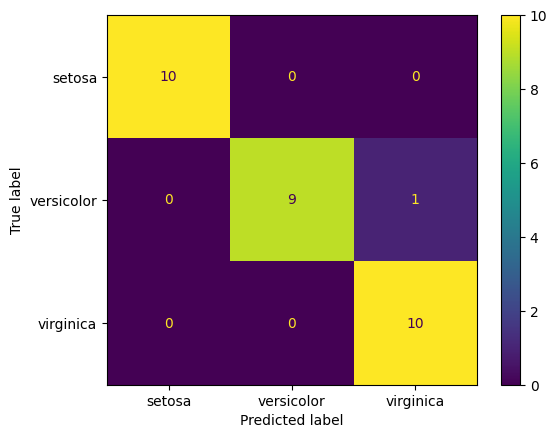

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

labels = list(range(len(data.target_names)))

cm_train = confusion_matrix(y_train_cls, y_train_pred_cls, labels=labels)
cm_test = confusion_matrix(y_test_cls, y_test_pred_cls, labels=labels)

print("Confusion matrix (train):")
display(pd.DataFrame(cm_train, index=data.target_names, columns=data.target_names))

print("Confusion matrix (test):")
display(pd.DataFrame(cm_test, index=data.target_names, columns=data.target_names))

# Optional visualization
fig, ax = plt.subplots()
ConfusionMatrixDisplay(cm_test, display_labels=data.target_names).plot(ax=ax)
plt.show()


## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [ ]:
# Bonus (optional): try a couple of alternative models and compare metrics quickly.

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, balanced_accuracy_score, f1_score

# --- Regression: RandomForestRegressor ---
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train_reg, y_train_reg)
rf_test_pred = rf.predict(X_test_reg)

print("Regression comparison (test set):")
print(f"  LinearRegression -> R2: {r2_test:.4f}, MSE: {mse_test:.2f}, MAE: {mae_test:.2f}")
print(f"  RandomForest     -> R2: {r2_score(y_test_reg, rf_test_pred):.4f}, "
      f"MSE: {mean_squared_error(y_test_reg, rf_test_pred):.2f}, "
      f"MAE: {mean_absolute_error(y_test_reg, rf_test_pred):.2f}")

# --- Classification: KNN ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_cls, y_train_cls)
knn_test_pred = knn.predict(X_test_cls)

print("\nClassification comparison (test set):")
print(f"  LogisticRegression -> Acc: {acc_test:.4f}, BalAcc: {bacc_test:.4f}, F1(macro): {f1_test:.4f}")
print(f"  KNN (k=5)          -> Acc: {accuracy_score(y_test_cls, knn_test_pred):.4f}, "
      f"BalAcc: {balanced_accuracy_score(y_test_cls, knn_test_pred):.4f}, "
      f"F1(macro): {f1_score(y_test_cls, knn_test_pred, average='macro'):.4f}")


Regression comparison (test set):
  LinearRegression -> R2: 0.6688, MSE: 24.29, MAE: 3.19
  RandomForest     -> R2: 0.8783, MSE: 8.93, MAE: 2.08

Classification comparison (test set):
  LogisticRegression -> Acc: 0.9667, BalAcc: 0.9667, F1(macro): 0.9666
  KNN (k=5)          -> Acc: 1.0000, BalAcc: 1.0000, F1(macro): 1.0000
